<a href="https://colab.research.google.com/github/RiazullJannat/ML/blob/main/simple_liner_regration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# X represents our 'Feature' (the data we use to make predictions)
X = np.array([1 , 3, 4, 6, 7]) # Years of experience

# y represents our 'Target' (the value we want our model to learn to predict)
y = np.array([15, 35, 45, 65, 70]) # Salary in thousands

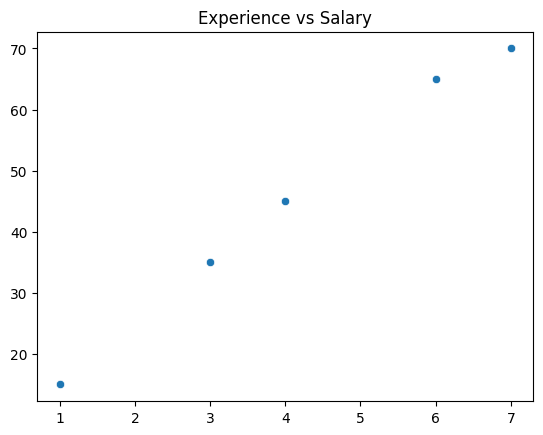

In [55]:
sns.scatterplot(x=X, y=y)
plt.title("Experience vs Salary")
plt.show()

In [56]:
def make_prediction(x,y,w,b):
  m = x.shape[0]
  pred_list = np.zeros((m,))


  for i in range(m):
    pred_list[i] = w*x[i]+b
  return pred_list

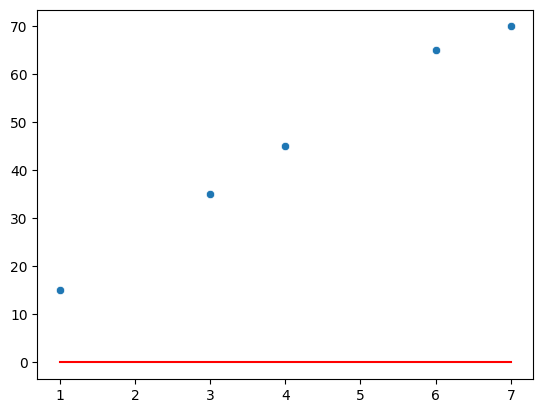

In [57]:
predictions = make_prediction(X, y, 0,0)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color="red", label="model line")
plt.show()

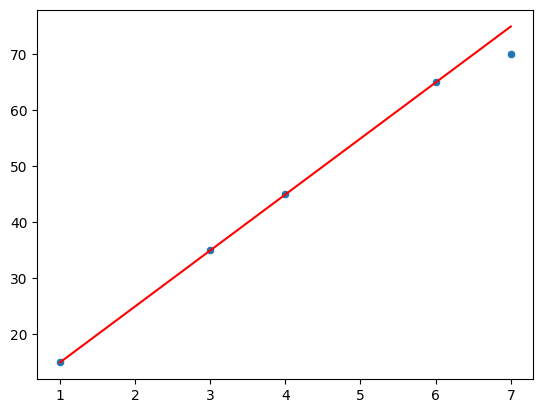

In [58]:
predictions = make_prediction(X, y, 10,5)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, color="red", label="model line")
plt.show()

In [59]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0.0

    for i in range(m):
        f_wb = w * x[i] + b
        cost_sum += (f_wb - y[i]) ** 2
    total_cost = cost_sum / (2 * m)

    return total_cost



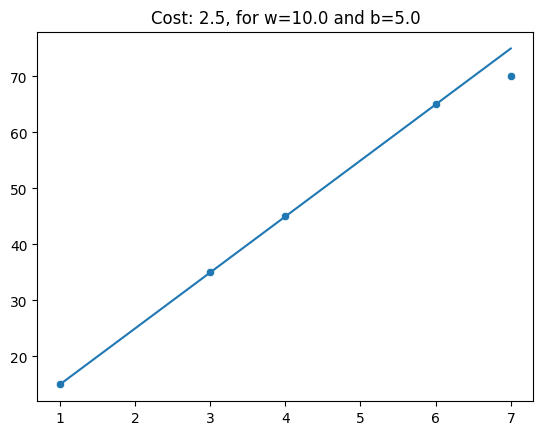

In [60]:
w = 10.0
b = 5.0


predictions = make_prediction(X, y, w=w, b=b)

sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)
# The title shows the cost, helping us see how 'wrong' our line is
plt.title(f"Cost: {compute_cost(X, y, w=w, b=b)}, for w={w} and b={b}")
plt.show()

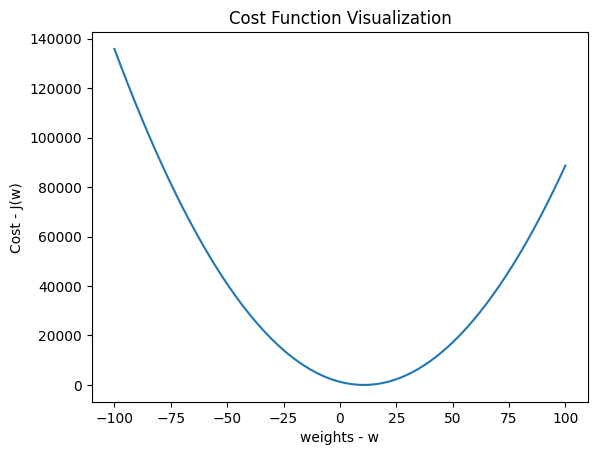

In [61]:
w_range=[]
cost_history=[]

for i in range(-100,101):
  cost_i = compute_cost(x=X,y=y,w=i,b=0)
  w_range.append(i)
  cost_history.append(cost_i)


plt.plot(w_range, cost_history)
plt.xlabel("weights - w")
plt.ylabel("Cost - J(w)")
plt.title("Cost Function Visualization")
plt.show()

In [62]:
##Calculate gradient Decent value:-

def calculate_gradient(X,y,w,b):
  m = X.shape[0]
  dj_dw=0.0
  dj_db=0.0

  for i in range(m):
    prediction = w*X[i]+b
    error= prediction - y[i]
    dj_dw+=error*X[i]
    dj_db+=error
  return dj_dw/m,dj_db/m

w = 3.0
b=0.0
calculate_gradient(X,y,w,b)



(np.float64(-169.4), np.float64(-33.4))

In [63]:
def gradient_descent(X,y,w_inp,b_inp,max_itr,alpha):
  w=w_inp
  b=b_inp
  cost_memo = []
  iteration = []
  for i in range(max_itr):
    dj_dw,dj_db = calculate_gradient(X,y,w,b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    cost = compute_cost(X, y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

     # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")


  return w, b, cost_memo, iteration


In [69]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_inp=0, b_inp=0, max_itr=10000, alpha=0.01)

Iteration 0: Cost 790.3717, w: 2.4300, b: 0.4700
Iteration 100: Cost 0.6120, w: 10.4659, b: 2.5593
Iteration 200: Cost 0.4115, w: 10.3821, b: 2.9986
Iteration 300: Cost 0.2767, w: 10.3133, b: 3.3588
Iteration 400: Cost 0.1861, w: 10.2569, b: 3.6542
Iteration 500: Cost 0.1251, w: 10.2107, b: 3.8965
Iteration 600: Cost 0.0841, w: 10.1727, b: 4.0951
Iteration 700: Cost 0.0566, w: 10.1416, b: 4.2580
Iteration 800: Cost 0.0380, w: 10.1162, b: 4.3915
Iteration 900: Cost 0.0256, w: 10.0952, b: 4.5010
Iteration 1000: Cost 0.0172, w: 10.0781, b: 4.5909
Iteration 1100: Cost 0.0116, w: 10.0640, b: 4.6645
Iteration 1200: Cost 0.0078, w: 10.0525, b: 4.7249
Iteration 1300: Cost 0.0052, w: 10.0431, b: 4.7744
Iteration 1400: Cost 0.0035, w: 10.0353, b: 4.8150
Iteration 1500: Cost 0.0024, w: 10.0290, b: 4.8483
Iteration 1600: Cost 0.0016, w: 10.0237, b: 4.8756
Iteration 1700: Cost 0.0011, w: 10.0195, b: 4.8980
Iteration 1800: Cost 0.0007, w: 10.0160, b: 4.9164
Iteration 1900: Cost 0.0005, w: 10.0131, b

Optimized w: 10.0000, b: 5.0000


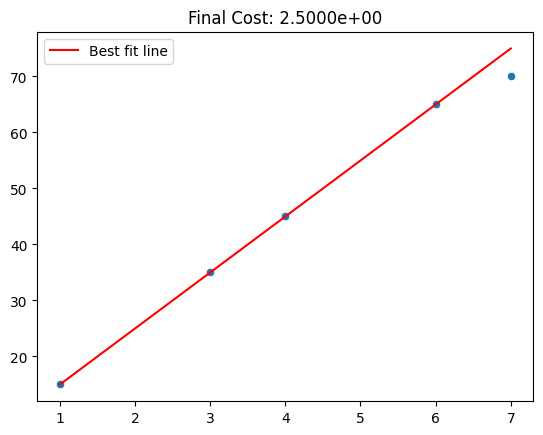

In [73]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Get final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [74]:
# Example: Predicting salary for someone with 2 years of experience
x_new = 2

# Using the formula f(x) = wx + b with our final calculated parameters
prediction = w_final * x_new + b_final
print(f"Predicted salary for {x_new} years of experience: {prediction:0.2f}k")

Predicted salary for 2 years of experience: 25.00k


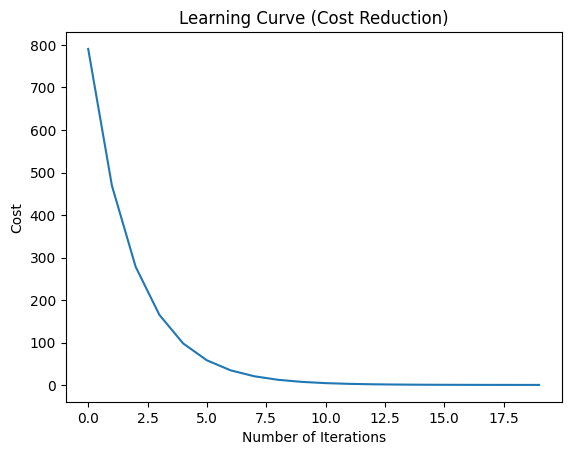

In [75]:
plt.plot(iter_list[:20], cost_memo[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()